In [ ]:
# 🤖 Titanic Survival Prediction — Machine Learning Models

## Project Overview
A comparative machine learning study to predict passenger 
survival on the Titanic using two classification algorithms.
This project follows the complete ML pipeline from data 
preprocessing to model evaluation and comparison.

## Problem Statement
**Can we predict whether a Titanic passenger survived 
based on their demographic and ticket information?**

## Dataset
| Property | Details |
|----------|---------|
| Source | Titanic passenger records (1912) |
| Total Records | 891 passengers |
| Features Used | 6 (Pclass, Sex, Age, SibSp, Parch, Fare) |
| Target Variable | Survived (0 = Died, 1 = Survived) |

## Methodology
Data Loading & Cleaning
Feature Selection & Engineering
Train/Test Split (80% / 20%)
Model Training & Evaluation
Model Comparison & Analysis

## Algorithms Compared
- **Logistic Regression** — mathematical probability model
- **Decision Tree** — flowchart based decision model

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df=pd.read_csv(url)

print('Data Loaded')
print(df.shape)

Data Loaded
(891, 12)


In [3]:
# Select useful columns for prediction
# We drop Name, Ticket, Cabin - not useful for ML
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
target = 'Survived'

# Fix missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Convert Sex to numbers
# ML can't read 'male'/'female' — needs 0 and 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Create X (features) and y (target)
X = df[features]
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFirst 5 rows of X:")
print(X.head())

Features shape: (891, 6)
Target shape: (891,)

First 5 rows of X:
   Pclass  Sex   Age  SibSp  Parch     Fare
0       3    0  22.0      1      0   7.2500
1       1    1  38.0      1      0  71.2833
2       3    1  26.0      0      0   7.9250
3       1    1  35.0      1      0  53.1000
4       3    0  35.0      0      0   8.0500


In [4]:
# Split data into training and testing
# test_size=0.2 means 20% for testing
# random_state=42 means same split every time
# (42 is just a convention — any number works!)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print(f"\nTraining: {len(X_train)} passengers")
print(f"Testing: {len(X_test)} passengers")

Training size: (712, 6)
Testing size: (179, 6)

Training: 712 passengers
Testing: 179 passengers


In [5]:
# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model — computer learns from training data
model.fit(X_train, y_train)

# Test the model — predict on testing data
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 81.01%


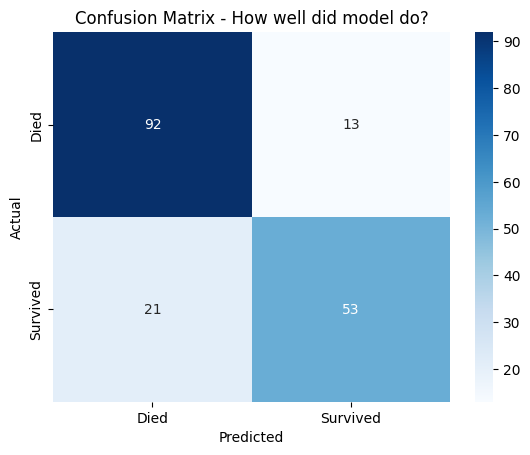

In [6]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix shows correct and wrong predictions
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died','Survived'],
            yticklabels=['Died','Survived'])
plt.title('Confusion Matrix - How well did model do?')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

dt_model=DecisionTreeClassifier(max_depth=5, random_state=42)

dt_model.fit(X_train, y_train)
dt_pred=dt_model.predict(X_test)
dt_accuracy=accuracy_score(y_test, dt_pred)

print(f"Decision Tree Accuracy: {dt_accuracy:.2%}")
print(f"Logistic Regression Accuracy: 81.01%")

Decision Tree Accuracy: 80.45%
Logistic Regression Accuracy: 81.01%


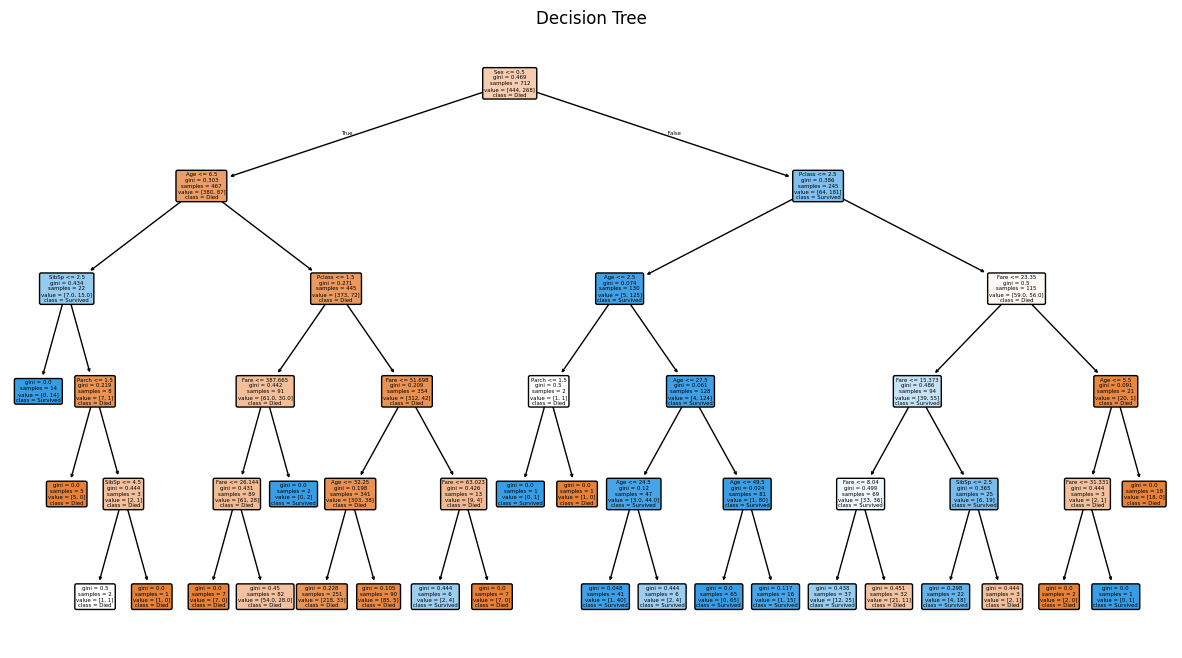

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,8))
tree.plot_tree(dt_model,
    feature_names=features,
    class_names=['Died', 'Survived'],
    filled=True,
    rounded=True)
plt.title('Decision Tree')
plt.show()
           

In [ ]:
## 📊 Model Performance Summary

| Model | Configuration | Accuracy |
|-------|--------------|---------|
| Logistic Regression | max_iter=1000 | **81.01%** ✅ |
| Decision Tree | max_depth=3 | 79.89% |
| Decision Tree | max_depth=5 | 80.45% |
| Decision Tree | max_depth=10 | 78.21% ❌ |

## 🔍 Confusion Matrix Analysis — Best Model
*(Logistic Regression — 81.01%)*

| | Predicted Died | Predicted Survived |
|--|---------------|-------------------|
| **Actual Died** | 92 ✅ | 13 ❌ |
| **Actual Survived** | 21 ❌ | 53 ✅ |

- True Positives (Survived correctly): 53
- True Negatives (Died correctly): 92
- False Positives (Said survived, actually died): 13
- False Negatives (Said died, actually survived): 21

## 📌 Key Findings

**1. Logistic Regression outperformed Decision Tree**
- Simple mathematical model beat flowchart model
- Proves: complexity ≠ better performance

**2. Overfitting detected in Decision Tree**
- Depth 5 → 80.45% (good)
- Depth 10 → 78.21% (overfit — memorized training data)
- Deeper tree = more questions = less generalizable

**3. Model Interpretability**
- Decision Tree depth 3 = visually simple and explainable
- Decision Tree depth 10 = impossible to interpret
- Simple models are preferred in business settings

## 💡 Technical Learnings
- Overfitting occurs when model is too complex
- max_depth controls Decision Tree complexity
- Always compare multiple models before concluding
- Train/test split prevents data leakage
- 80/20 split is industry standard

## 🎯 Conclusion
Logistic Regression achieved 81.01% accuracy —
correctly predicting survival for 145 out of 179 
test passengers. This confirms our earlier EDA findings:
**gender and passenger class were the strongest 
predictors of survival on the Titanic.**

*Best Model: Logistic Regression — 81.01% Accuracy*